# Análisis ConnectaTel

Objetivo: Evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

/Users/ulisesvillegas/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### Exploración de la estructura de los datasets

**Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.  

In [6]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      str    
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes


In [8]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


In [9]:
usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB




###  Revisión de valores nulos

- Objetivo:
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.



In [10]:
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- Hay columnas con valores faltantes: city(11%) y churn_date (88%).
- churn_date podemos ignorarlo o eliminar y city imputar.


In [12]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador único secuencial, se excluye del análisis estadístico por no representar una variable de negocio.
- La columna `age` parece haber sentinels (-999) que debemos eliminar.

In [13]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [14]:
usage.groupby('type')[['duration', 'length']].count()

,duration,length
type,,
call,17908,12
text,16,22092


In [15]:
# Mensajes que tienen un valor "inesperado" en duration
usage[(usage['type'] == 'text') & (usage['duration'].notna())]

,id,user_id,type,date,duration,length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.0,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.0,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.0,69.0
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.0,68.0
11456,11457,13325,text,2024-02-21 20:09:09.733743343,120.0,23.0
16702,16703,10484,text,2024-03-16 13:52:57.169429235,120.0,48.0
22814,22815,12711,text,2024-04-13 05:39:44.429610740,120.0,70.0
23052,23053,13850,text,2024-04-14 07:30:35.235880896,120.0,24.0
23451,23452,13265,text,2024-04-16 02:50:32.175804394,120.0,53.0
26561,26562,13920,text,2024-04-30 04:35:48.173704342,120.0,89.0


In [16]:
# Llamadas que tienen un valor "inesperado" en length
usage[(usage['type'] == 'call') & (usage['length'].notna())]

,id,user_id,type,date,duration,length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,1490.0
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.40,1490.0
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,1490.0
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,1490.0
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,1490.0
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,1490.0


- Las columnas `id` y `user_id` son identificadores unicos, no representan variables estadisticas de negocio a analizar.
- Hallazgo en los datos de tipo "text", estos representan mensajes de texto, por lo tanto, no debería de haber datos en "duration", en este caso aparecen "120" estandarizado, lo mejor sería reemplazar estos datos por NA.
- Hallazgo en los datos de tipo "call", estos representan llamadas, por lo tanto no debería haber datos en la columna "length", aparecen "1490" estandarizados, en este caso como en el anterior se deben reemplazar por NA.

In [17]:
# Reemplazar duration por NaN cuando el tipo es 'text' (no debería tener duración)
usage.loc[usage['type'] == 'text', 'duration'] = np.nan

# Verificar
usage.groupby('type')[['duration', 'length']].count()

,duration,length
type,,
call,17908,12
text,0,22092


In [18]:
# Reemplazar duration por NaN cuando el tipo es 'text' (no debería tener duración)
usage.loc[usage['type'] == 'call', 'length'] = np.nan

# Verificar
usage.groupby('type')[['duration', 'length']].count()

,duration,length
type,,
call,17908,0
text,0,22092


In [19]:
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- En la columna `city` hay 469 valores faltantes (4000 - 3531). Bogotá concentra una porción importante de los usuarios, aunque no domina de forma abrumadora (808 de 3531 registros válidos ≈ 23%, dejando el resto repartido entre las otras 6 ciudades).
- En la columna `plan` la base de usuarios está mayoritariamente concentrada en el plan Básico (casi 2 de cada 3 usuarios), con Premium representando la minoría (~35%).

In [20]:
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 4000 datos almacenados, de los cuales predominan los mensajes de texto, representando el 55.23% de los datos, el porcentaje restante lo representan las llamadas.


---

**Valores inválidos o sentinels**  
- En la columna age, hay sentinels(-999), en el dataset "usage" hay valores que no son correctos para las categorias 'text' y 'call'
- Se reemplazó los valores incorrectos por NA en el dataset "usage" y se debe hacer una limpieza para los sentinels encontrados en la columna "age" del dataset "users".

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"])

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"])

In [23]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024], dtype=int32)

En `reg_date` se observan los años "2022, 2023, 2024 y 2026", 2026 no es una fecha que haya transcurrido al momento de tener el dataset.

In [24]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

En `date`, se observa lo mismo, hay datos con el año 2026, habra que reemplazar los datos por NA.

In [25]:
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
users["city"] = users["city"].replace("?", np.nan)
users["city"] = users["city"].replace("NA", np.nan)

print(users["city"].isna().sum())
print(users["city"].unique())

565
<StringArray>
['Medellín', nan, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali']
Length: 7, dtype: str


In [27]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT
# Verificar cambios
users["reg_date"].isna().sum()         
users["reg_date"].dt.year.unique() 

array([2022.,   nan, 2023., 2024.])

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    1.0
call    0.0
Name: duration, dtype: float64

In [29]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    1.0
text    0.0
Name: length, dtype: float64

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [33]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,reg_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3960,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,2023-07-03 21:39:41.095273728,5.524381,4.478120,22.836934
min,10000.000000,18.000000,2022-01-01 00:00:00,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022-10-02 20:17:11.657914368,4.000000,3.000000,11.095000
50%,11999.500000,47.000000,2023-07-04 10:00:05.401350400,5.000000,4.000000,19.740000
75%,12999.250000,63.000000,2024-04-03 04:00:05.401350400,7.000000,6.000000,31.185000
max,13999.000000,79.000000,2024-12-31 00:00:00,17.000000,15.000000,155.690000
std,1154.844867,17.690408,NaN,2.358416,2.144238,16.590213


In [34]:
# Distribución porcentual del tipo de plan
(user_profile["plan"].value_counts(normalize=True) * 100).round(2)

plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64

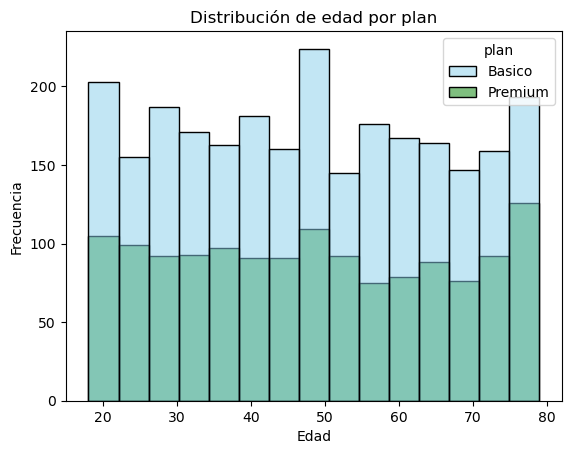

In [35]:
# Histograma para visualizar la edad (age)


sns.histplot(data=user_profile, x="age", hue="plan", bins=15, 
             palette=["skyblue", "green"], edgecolor="black")
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- La distribución de edad es uniforme entre 18 y 80 años, sin sesgo marcado.
La proporción de planes Básico/Premium se mantiene consistente (~65%/35%), sugiriendo que el tipo de plan no está fuertemente asociado a la edad.
- El grupo de mayor edad (75-80) muestra una proporción de Premium más alta de lo esperado, 
aunque esto requiere validación adicional dado el menor tamaño de muestra en ese rango.

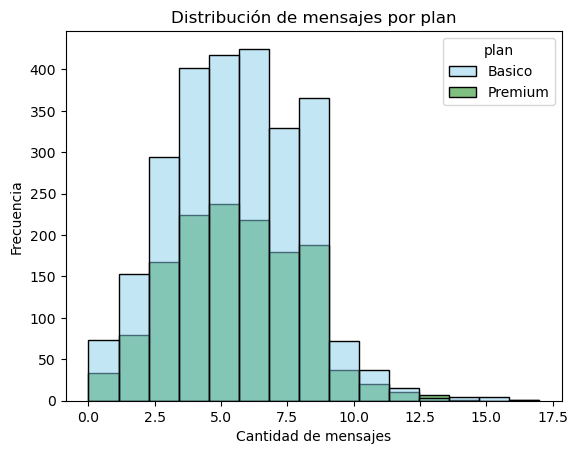

In [36]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=15, 
             palette=["skyblue", "green"], edgecolor="black")
plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- La distribución de cant_mensajes muestra forma normal con sesgo leve 
hacia la derecha, concentrada entre 4 y 8.5 mensajes (coincide con mediana=5, media=5.52).
La proporción Básico/Premium se mantiene relativamente estable en todos los rangos de 
mensajes, sin evidencia fuerte de que el plan influya en el volumen de mensajes enviados.
Se identifica un grupo de usuarios con 0 mensajes que podría merecer análisis adicional 
(usuarios nuevos, inactivos, o que solo utilizan el servicio de llamadas).

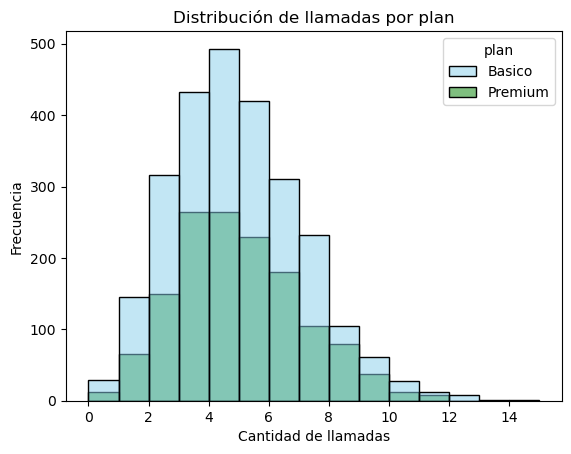

In [37]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=15, 
             palette=["skyblue", "green"], edgecolor="black")
plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de cant_llamadas muestra sesgo leve a la derecha, concentrada entre 
3 y 6 llamadas (coincide con mediana=4, media=4.48). A diferencia de cant_mensajes, 
aquí SÍ se observa una relación notable con el plan: los usuarios Premium están 
sobre-representados en el rango de mayor frecuencia (3-6 llamadas), alcanzando 
proporciones cercanas al 50%.
- Esto sugiere que el plan Premium está asociado a un mayor volumen de llamadas, 
consistente con el patrón ya observado en cant_minutos_llamada.

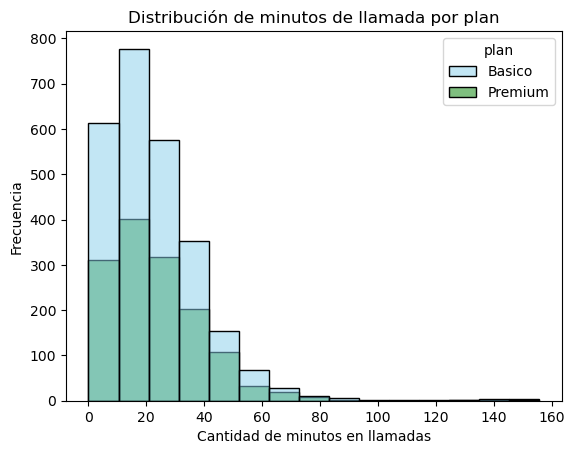

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=15, 
             palette=["skyblue", "green"], edgecolor="black")
plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("Cantidad de minutos en llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de cant_minutos_llamada presenta el sesgo positivo más pronunciado 
de las cuatro variables analizadas, con una cola larga hacia valores altos (hasta 155 min) 
que coincide con los 109 outliers detectados previamente vía IQR.
- El plan Premium está asociado consistentemente a mayor 
volumen de llamadas y mayor duración total de las mismas, un patrón de negocio 
coherente que sugiere que los usuarios Premium son, en efecto, consumidores más 
intensivos del servicio de llamadas a diferencia de cant_mensajes, donde el plan 
no mostró relación significativa con el comportamiento.

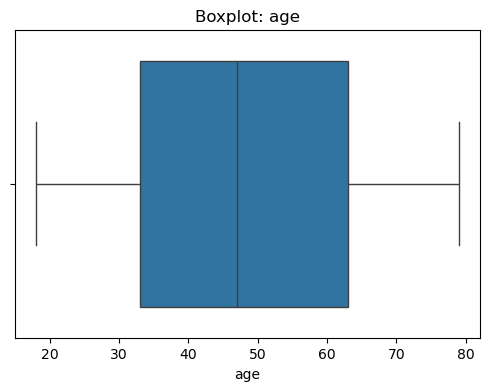

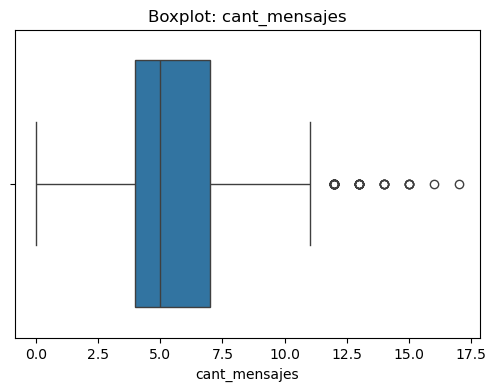

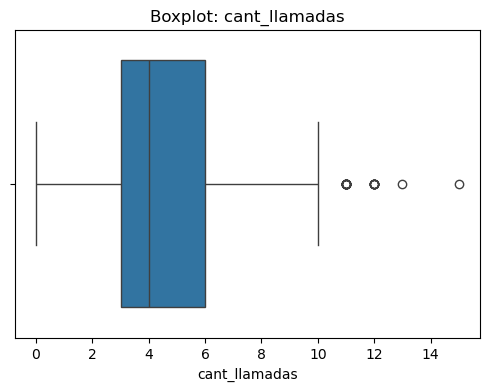

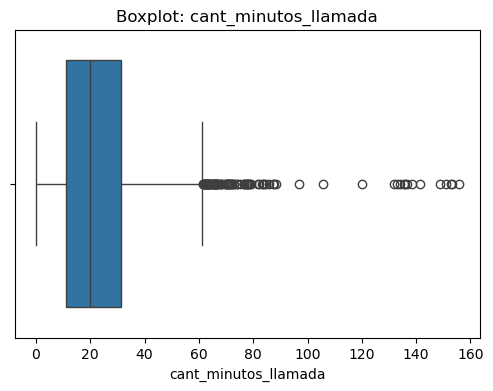

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=user_profile[col])
        plt.title(f'Boxplot: {col}')
        plt.xlabel(col)
        plt.show()

💡Insights: 
- Age: No muestra outliers.
- cant_mensajes: Muestra claramente 6 outliers en valores altos.
- cant_llamadas: Muestra 4 outliers en valores altos
- cant_minutos_llamada: Muestra lo que concluímos en la interpretación del histograma, hay valores altos fuera del rango intercuartil, muchos outliers.

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
print("Primer cuartil:", Q1)
print("Tercer cuartil:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Primer cuartil: 11.094999999999999
Tercer cuartil: 31.185
IQR: 20.09
Limite inferior: -19.04
Limite superior: 61.31999999999999


In [41]:
limite_superior = 31.415 + 1.5 * 20.295
outliers = user_profile[user_profile['cant_minutos_llamada'] > limite_superior]
print(outliers.shape[0], 'de', user_profile.shape[0])
print(outliers['cant_minutos_llamada'].describe())
outliers['plan'].value_counts()
print(user_profile['plan'].value_counts(normalize=True) * 100)

93 de 4000
count     93.000000
mean      82.101828
std       26.300655
min       62.110000
25%       65.790000
50%       71.570000
75%       83.060000
max      155.690000
Name: cant_minutos_llamada, dtype: float64
plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64


In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print("Mediana:")
print(user_profile[columnas_limites].median())
print("Media:")
print(user_profile[columnas_limites].mean())
user_profile[columnas_limites].describe()

Mediana:
age                     47.00
cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.74
dtype: float64
Media:
age                     48.122250
cant_mensajes            5.524381
cant_llamadas            4.478120
cant_minutos_llamada    22.836934
dtype: float64


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,22.836934
std,17.690408,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,47.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- Distribuciones sesgadas a la derecha (right-skewed).
- Valores atípicos altos, visibles en los máximos por encima del percentil 75.
- Medias poco arriba de la mediana, no muy significativo.
- Media y mediana prácticamente iguales.
- Los valores extremos tienen poco impacto en las métricas centrales.

  
- En las columnas; "cant_mensajes,cant_llamadas lo mejor es mantener los outliers ya que parecen tener poco impacto en las metricas centrales.
- Para la columna cant_minutos_llamadas podemos detectar que hay mas valores atipicos, el maximo valor parece si afectar un poco mas las metricas centrales; estos valores altos no son errores de captura, sino un patrón real, son usuarios (proporcionalmente más Premium) que efectivamente hablan mucho más que el promedio. No es un patrón aleatorio ni sospechoso — es coherente con lo que se esperaría del negocio.

 

---

In [43]:
# Crear columna grupo_uso
def classify_use(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] <  5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"] = user_profile.apply(classify_use, axis = 1)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [45]:
# Crear columna grupo_edad
def classify_age(row):
    if row["age"] < 30:
        return "Joven"
    elif row["age"] < 60:
        return "Adulto"
    else:
        return "Adulto mayor"
user_profile["grupo_edad"] = user_profile.apply(classify_age, axis = 1)

In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


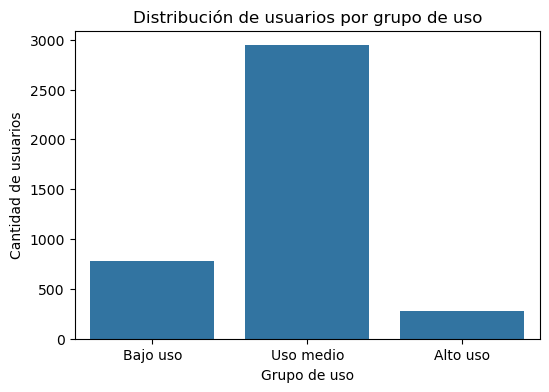

In [47]:

# Visualización de los segmentos por uso

plt.figure(figsize=(6, 4))
sns.countplot(x='grupo_uso', data=user_profile, order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

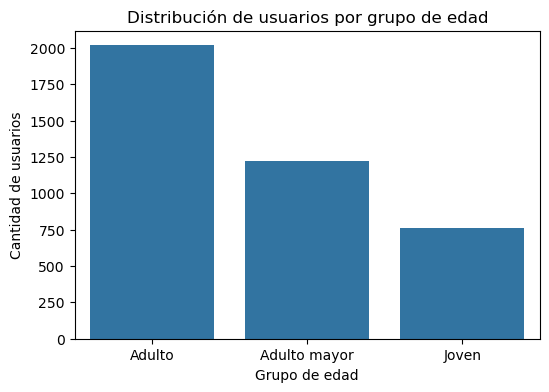

In [48]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6, 4))
sns.countplot(x='grupo_edad', data=user_profile)
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? Se encontraron errores en la captura de datos, valores atipicos que fueron reemplazados por "NA", no era muy significativo a nivel percentil, pero si debían de ser limpiados.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso? Por diferencia significativa se muestra que los adultos representan la mayor cantidad de usuarios, seguido de adulto mayor y por ultimo jovenes. El uso se concentra mayormente en un "uso medio".  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? El grupo de edad que mas usa la linea telefonica y el uso que se le da, la frecuencia y tipo de comunicacion que mas usan. 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? El plan Premium está asociado consistentemente a mayor volumen de llamadas y mayor duración total de las mismas, un patrón de negocio coherente que sugiere que los usuarios Premium son consumidores más intensivos del servicio de llamadas.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados? Valdría la pena tener una buena atención al grupo de edad "Adulto-premium"


In [49]:
user_profile["grupo_edad"].value_counts(normalize=True)*100

grupo_edad
Adulto          50.45
Adulto mayor    30.55
Joven           19.00
Name: proportion, dtype: float64

In [50]:
user_profile["grupo_uso"].value_counts(normalize=True)*100

grupo_uso
Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: proportion, dtype: float64

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Sentinels.
- Información invalida.


🔍 **Segmentos por Edad**
- Las personas adultas entre 30 y 60 años son la mayoría de usuarios activos representando un 50% de la muestra.



📊 **Segmentos por Nivel de Uso**
-  Las personas que usan entre 5 a 10 llamadas y mensajes en su linea telefonica son la mayoría de usuarios representando un 73% sobre la muestra.



➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Se le de prioridad a la atencion a clientes entre 30 a 60 años.
- Explorar por qué los extremos de edad (18-30 y 60-80) tienen menor participación — ¿es una limitación del producto (interfaz poco amigable para adultos mayores, por ejemplo), falta de alcance de marketing hacia jóvenes, o simplemente refleja el perfil demográfico del mercado objetivo? Esto nos contestarí si conviene invertir en crecer esos segmentos o simplemente aceptar que no son el público natural del producto.
- El grupo de "uso medio" es el núcleo del negocio, entonces priorizar su experiencia y satisfacción, ya que cualquier cambio en producto/precio que los afecte tiene un impacto desproporcionado sobre el total de usuarios.
- El tipo de plan Premium está asociado a mayor uso de llamada, hay una oportunidad clara: el 73% de usuarios de uso medio es el público ideal para campañas de upgrade a Premium, ya que están cerca del comportamiento con ese plan.